In [79]:
# Instalaciones

%pip install nbformat
%pip install plotly


In [80]:
#Importaciones

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px
import seaborn as sns
import nbformat
import matplotlib.ticker as ticker
import scipy.stats as stats
import statsmodels.api as sm
import sklearn
from matplotlib import style



#Ignorar las advertencias de paquetes y sus actualizaciones
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor


#Preprocesamiento y Modelo

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression


#Configuracion de nuestro visuales

plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set(style = 'darkgrid', palette = 'pastel', color_codes = True)
sns.set_context('talk')


In [81]:
#Importar archivo

# Definir el esquema de columnas
columnas = ["Indice","TV", "Radio", "Periodico", "Ventas"]

df_Publicidad = pd.read_csv("/content/Publicidad.csv",sep=',',header=None,names = columnas,index_col=False,encoding='latin-1')

df_Publicidad = df_Publicidad.drop(df_Publicidad.iloc[:, 0].name, axis=1)
df_Publicidad = df_Publicidad.drop(df_Publicidad.iloc[0, :].name, axis=0)



# EDA

In [82]:
df_Publicidad.head(10)

,TV,Radio,Periodico,Ventas
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


In [83]:
df_Publicidad.tail(10)

,TV,Radio,Periodico,Ventas
191,39.5,41.1,5.8,10.8
192,75.5,10.8,6.0,9.9
193,17.2,4.1,31.6,5.9
194,166.8,42.0,3.6,19.6
195,149.7,35.6,6.0,17.3
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,8.6,8.7,13.4


In [84]:
# Identificar si existen valores nulos

df_Publicidad.isnull().sum()

,0
TV,0
Radio,0
Periodico,0
Ventas,0


In [85]:
# Resumido

df_Publicidad.select_dtypes(include=np.number).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.04,85.85,0.7,74.38,149.75,218.82,296.4
Radio,200.0,23.26,14.85,0.0,9.98,22.90,36.52,49.6
Periodico,200.0,30.55,21.78,0.3,12.75,25.75,45.10,114.0
Ventas,200.0,14.02,5.22,1.6,10.38,12.90,17.40,27.0


In [86]:
df_Publicidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Periodico  200 non-null    float64
 3   Ventas     200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# Distribución de las variables

Determinar cantidad de bins

In [87]:
#Formula de Sturges

import math

def sturges_formula(n):
  k = 1 +3.32 * math.log10(n)
  return round(k)

n = 200 # reemplazar con la cantidad de filas del set de datos
num_bins = sturges_formula(n)
print('Numero de bines segun la formula de Sturges es: ', num_bins)

Numero de bines segun la formula de Sturges es:  9


Distribución variable TV

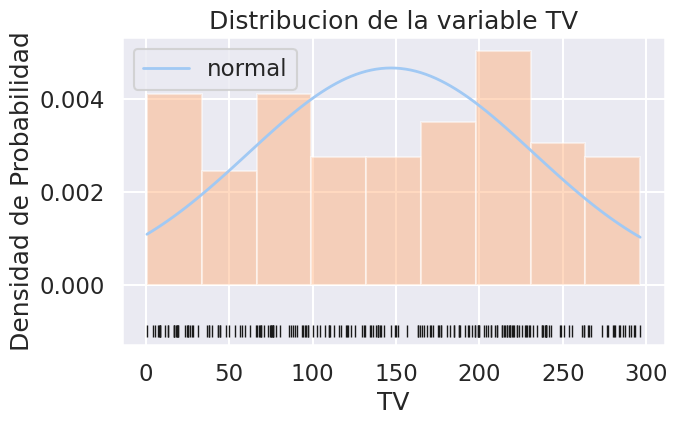

In [88]:
## Histograma + curva normal teorica

#Valores de la media (mu) y desviacion estandar (sigma) de los datos

mu, sigma = stats.norm.fit(df_Publicidad['TV'])

#Valores Teorico de la normaliadd del rango observado
x_hat = np.linspace(df_Publicidad['TV'].min(), df_Publicidad['TV'].max(), num=100)
y_hat = stats.norm.pdf(x_hat, mu , sigma)

#Grafico
fig, ax = plt.subplots(figsize = (7,4))
ax.plot(x_hat, y_hat , linewidth = 2, label = 'normal')
ax.hist(x = df_Publicidad['TV'], density= True, bins=num_bins, alpha = 0.5)
ax.plot(df_Publicidad['TV'],np.full_like(df_Publicidad['TV'],-0.001),'|k',markeredgewidth = 1)
ax.set_title('Distribucion de la variable TV')
ax.set_xlabel('TV')
ax.set_ylabel('Densidad de Probabilidad')
ax.legend()
plt.show()

Distribución variable Radio

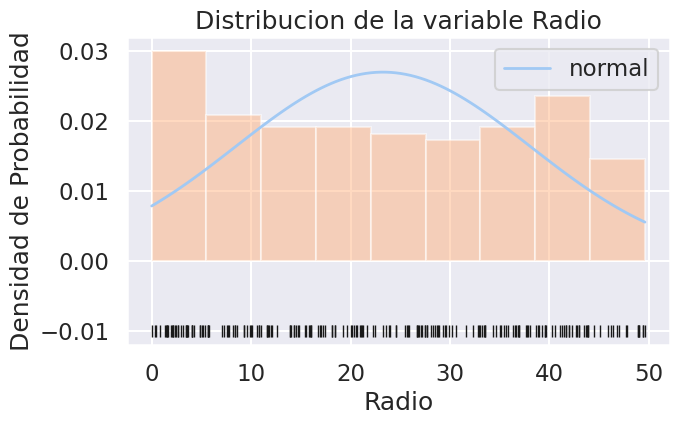

In [89]:
## Histograma + curva normal teorica

#Valores de la media (mu) y desviacion estandar (sigma) de los datos

mu, sigma = stats.norm.fit(df_Publicidad['Radio'])

#Valores Teorico de la normaliadd del rango observado
x_hat = np.linspace(df_Publicidad['Radio'].min(), df_Publicidad['Radio'].max(), num=100)
y_hat = stats.norm.pdf(x_hat, mu , sigma)

#Grafico
fig, ax = plt.subplots(figsize = (7,4))
ax.plot(x_hat, y_hat , linewidth = 2, label = 'normal')
ax.hist(x = df_Publicidad['Radio'], density= True, bins=num_bins, alpha = 0.5)
ax.plot(df_Publicidad['Radio'],np.full_like(df_Publicidad['Radio'],-0.01),'|k',markeredgewidth = 1)
ax.set_title('Distribucion de la variable Radio')
ax.set_xlabel('Radio')
ax.set_ylabel('Densidad de Probabilidad')
ax.legend()
plt.show()

Distribución variable Periodico

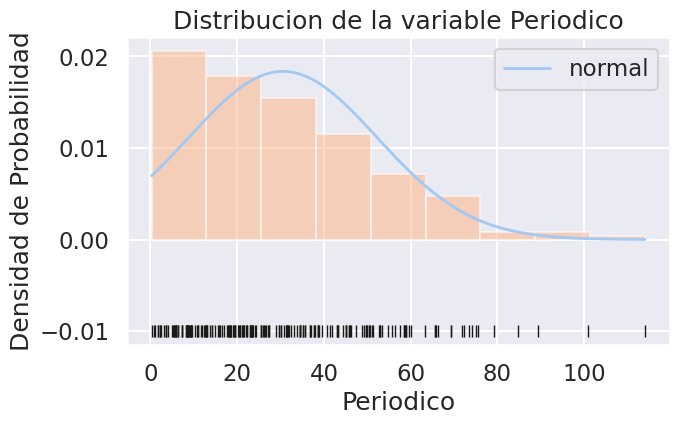

In [90]:
## Histograma + curva normal teorica

#Valores de la media (mu) y desviacion estandar (sigma) de los datos

mu, sigma = stats.norm.fit(df_Publicidad['Periodico'])

#Valores Teorico de la normaliadd del rango observado
x_hat = np.linspace(df_Publicidad['Periodico'].min(), df_Publicidad['Periodico'].max(), num=100)
y_hat = stats.norm.pdf(x_hat, mu , sigma)

#Grafico
fig, ax = plt.subplots(figsize = (7,4))
ax.plot(x_hat, y_hat , linewidth = 2, label = 'normal')
ax.hist(x = df_Publicidad['Periodico'], density= True, bins=num_bins, alpha = 0.5)
ax.plot(df_Publicidad['Periodico'],np.full_like(df_Publicidad['Periodico'],-0.01),'|k',markeredgewidth = 1)
ax.set_title('Distribucion de la variable Periodico')
ax.set_xlabel('Periodico')
ax.set_ylabel('Densidad de Probabilidad')
ax.legend()
plt.show()

Distribución variable Ventas

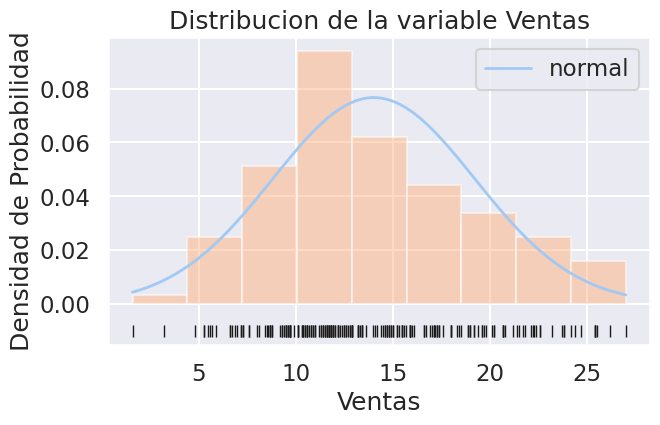

In [91]:
## Histograma + curva normal teorica

#Valores de la media (mu) y desviacion estandar (sigma) de los datos

mu, sigma = stats.norm.fit(df_Publicidad['Ventas'])

#Valores Teorico de la normaliadd del rango observado
x_hat = np.linspace(df_Publicidad['Ventas'].min(), df_Publicidad['Ventas'].max(), num=100)
y_hat = stats.norm.pdf(x_hat, mu , sigma)

#Grafico
fig, ax = plt.subplots(figsize = (7,4))
ax.plot(x_hat, y_hat , linewidth = 2, label = 'normal')
ax.hist(x = df_Publicidad['Ventas'], density= True, bins=num_bins, alpha = 0.5)
ax.plot(df_Publicidad['Ventas'],np.full_like(df_Publicidad['Ventas'],-0.01),'|k',markeredgewidth = 1)
ax.set_title('Distribucion de la variable Ventas')
ax.set_xlabel('Ventas')
ax.set_ylabel('Densidad de Probabilidad')
ax.legend()
plt.show()

# Gráficos de Dispersión

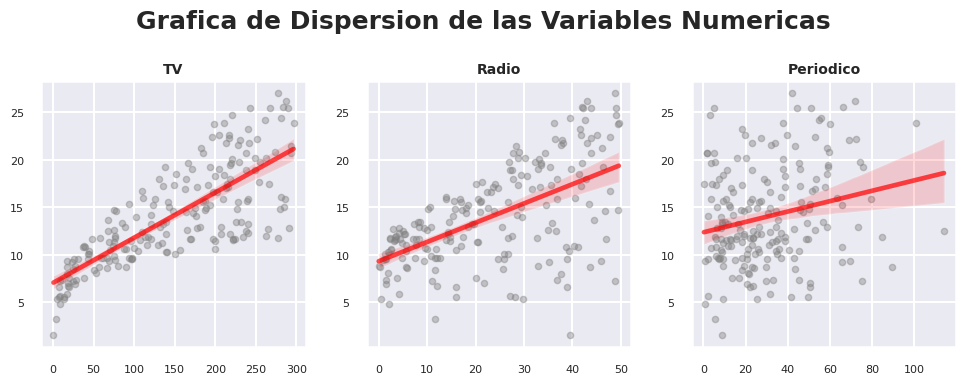

In [92]:
#Grafica de Dispersion para cada variable numerica y su relacion con la variable dependiente

fig,axes=plt.subplots(nrows=1,ncols=3,figsize=(10,4))
axes=axes.flat
columnas_numericas=df_Publicidad.select_dtypes(include=np.number).columns
columnas_numericas=columnas_numericas.drop('Ventas')

for i,columna in enumerate(columnas_numericas):
  sns.regplot(
    data=df_Publicidad,
    x=df_Publicidad[columna],
    y='Ventas',
    color = 'gray',
    marker = '.',
    scatter_kws= {'alpha': 0.4},
    line_kws = {'color':'red', 'alpha':0.7},
    ax = axes[i])

  axes[i].set_title(columna,fontsize=10,fontweight='bold')
  axes[i].tick_params(labelsize=8)
  axes[i].yaxis.set_major_formatter(ticker.EngFormatter())
  axes[i].xaxis.set_major_formatter(ticker.EngFormatter())
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

fig.tight_layout()
plt.subplots_adjust(top=0.8)
plt.suptitle('Grafica de Dispersion de las Variables Numericas',fontsize='medium',fontweight='bold')
plt.show()

# Mapa de correlaciones

In [93]:
# Correlacion entre Variables Numericas

def matriz_correlacion(corr_mat):
  """ Funcion para convertir una matrix de correlacion a un formato tipo DataFrame """
  corr_mat=corr_mat.stack().reset_index()
  corr_mat.columns=['variable_1','variable_2','correlacion']
  corr_mat= corr_mat.loc[corr_mat['variable_1']!=corr_mat['variable_2'],:]
  corr_mat['Absoluto']=np.abs(corr_mat['correlacion'])
  corr_mat=corr_mat.sort_values('Absoluto',ascending=False)
  return corr_mat


corr_matrix = df_Publicidad.select_dtypes(include = np.number).corr(method = 'pearson')
matriz_correlacion(corr_matrix).head(10)

,variable_1,variable_2,correlacion,Absoluto
3,TV,Ventas,0.782224,0.782224
12,Ventas,TV,0.782224,0.782224
7,Radio,Ventas,0.576223,0.576223
13,Ventas,Radio,0.576223,0.576223
6,Radio,Periodico,0.354104,0.354104
9,Periodico,Radio,0.354104,0.354104
11,Periodico,Ventas,0.228299,0.228299
14,Ventas,Periodico,0.228299,0.228299
2,TV,Periodico,0.056648,0.056648
8,Periodico,TV,0.056648,0.056648


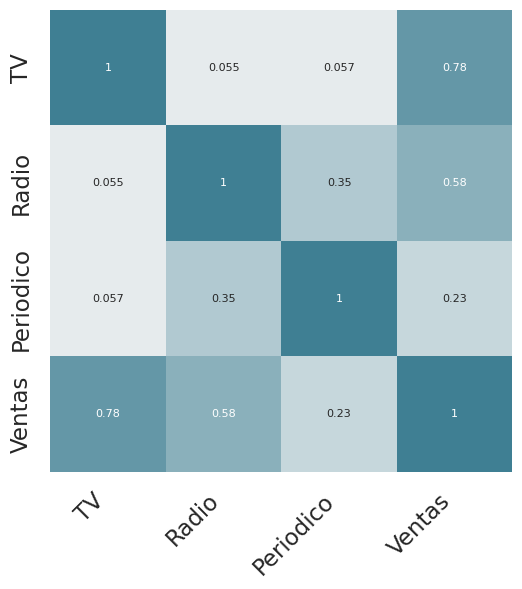

In [94]:
##HeatMap de Correlaciones

fig, axes = plt.subplots(nrows = 1, ncols =1, figsize = (6,6))

sns.heatmap(
    corr_matrix,
    cmap = sns.diverging_palette(20,220, n = 200),
    square = True,
    annot = True,
    center = 0,
    vmin = -1,
    vmax = 1,
    annot_kws = {'fontsize':8},
    cbar = False,
    ax = axes)

axes.set_xticklabels(axes.get_xticklabels(), rotation = 45, horizontalalignment = 'right')

plt.show()

# Modelo Regresión Lineal Simple

Se selecciona la varaible TV que tiene la mayor relación sobre ventas

In [95]:
import sklearn
# Cargar librerias

# Tratamiento de Datos

import pandas as pd
import numpy as np

#Graficos

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

#Preprocesamiento y Modelo

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

#Configuracion de nuestro visuales

plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')

#Ignorar las advertencias de paquetes y sus actualizaciones
import warnings
warnings.filterwarnings('ignore')

In [96]:
#Selección de variables

df_modelo = df_Publicidad[['TV','Ventas']]

In [97]:
# Division de los datos

X = df_modelo.drop(columns = 'Ventas')
y = df_modelo['Ventas']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y.values.reshape(-1,1),
    test_size = 0.2,
    random_state = 1234,
    shuffle = True)

In [98]:
# Crear y entrenar el modelo

modelo = LinearRegression()
modelo.fit(X = X_train, y = y_train)

LinearRegression()

In [99]:
# Predicciones del test

predicciones = modelo.predict(X= X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([15.4742994 , 14.20961031, 12.49391077, 17.8083947 , 12.01965236,
       17.04121198,  7.64903565, 12.833331  , 10.7968096 ,  7.85361771])

In [100]:
from sklearn.metrics import r2_score

r2_ols = r2_score(
    y_true  = y_test,
    y_pred = predicciones)

print(f'El coeficiente determinacion del test es: {r2_ols}')

El coeficiente determinacion del test es: 0.706345595455343


In [101]:
from sklearn.metrics import mean_squared_error

mse_ols = mean_squared_error(
    y_true  = y_test,
    y_pred = predicciones)

rmse_ols = np.sqrt(mse_ols)

print(f'El RMSE del test es: {rmse_ols}')

El RMSE del test es: 3.035025655113521


El coeficiente de determinación indica que el modelo tiene un poder predictivo razonable, y que la variable TV tiene una relación significativa sobre las ventas. Mientras que el RMSE me indica que el valor predicho se desvía en promedio 3 unidades.